In [3]:
import pandas as pd
import numpy as np

file_path = "../data/processed/cleaned_data.csv"
df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset loaded successfully!
Shape: (100000, 24)

Columns:
['Invoice_ID', 'Invoice_Date', 'City', 'Store_Format', 'Category', 'Brand', 'Channel', 'Payment_Mode', 'Units', 'Cost_Price', 'Selling_Price', 'Revenue', 'Cost', 'Margin', 'Margin_%', 'Stock_On_Hand', 'Reorder_Level', 'Lead_Time_Days', 'Customer_Age', 'Customer_Gender', 'Loyalty_Flag', 'Month', 'Day_of_Week', 'Year']


In [4]:
stock_ratio = df["Stock_On_Hand"] / df["Reorder_Level"]

df["Inventory_Health"] = np.where(
    stock_ratio < 1,
    "Low Stock",
    np.where(
        stock_ratio <= 2,
        "Healthy Stock",
        "Overstocked"
    )
)

print("Inventory Health distribution:")
print(df["Inventory_Health"].value_counts())

print("\nPercentage distribution:")
print(df["Inventory_Health"].value_counts(normalize=True) * 100)

Inventory Health distribution:
Inventory_Health
Overstocked      88795
Healthy Stock     9581
Low Stock         1624
Name: count, dtype: int64

Percentage distribution:
Inventory_Health
Overstocked      88.795
Healthy Stock     9.581
Low Stock         1.624
Name: proportion, dtype: float64


In [5]:

df["Stock_Ratio"] = df["Stock_On_Hand"] / df["Reorder_Level"]

print("Minimum:", df["Stock_Ratio"].min())
print("Maximum:", df["Stock_Ratio"].max())
print("Median:", df["Stock_Ratio"].median())

print("\nStock ratio percentiles:")
print(df["Stock_Ratio"].quantile([0.25, 0.50, 0.75]))

Minimum: 0.6329113924050633
Maximum: 24.95
Median: 5.541666666666667

Stock ratio percentiles:
0.25    3.274194
0.50    5.541667
0.75    8.345455
Name: Stock_Ratio, dtype: float64


In [6]:

def inventory_health(row):
    if row["Stock_Ratio"] < 3.27:
        return "Low Stock"
    elif row["Stock_Ratio"] <= 8.35:
        return "Healthy Stock"
    else:
        return "Overstocked"


df["Inventory_Health"] = df.apply(inventory_health, axis=1)

print(df["Inventory_Health"].value_counts())

print("\nPercentage:")
print(df["Inventory_Health"].value_counts(normalize=True) * 100)

Inventory_Health
Healthy Stock    50086
Overstocked      24964
Low Stock        24950
Name: count, dtype: int64

Percentage:
Inventory_Health
Healthy Stock    50.086
Overstocked      24.964
Low Stock        24.950
Name: proportion, dtype: float64


In [7]:
features = [
    "Units",
    "Selling_Price",
    "Revenue",
    "Margin",
    "Lead_Time_Days",
    "Customer_Age",
    "Loyalty_Flag",
    "Month",
    "Day_of_Week"
]

X = df[features]
y = df["Inventory_Health"]

print("Features:", features)
print("X shape:", X.shape)
print("y shape:", y.shape)

Features: ['Units', 'Selling_Price', 'Revenue', 'Margin', 'Lead_Time_Days', 'Customer_Age', 'Loyalty_Flag', 'Month', 'Day_of_Week']
X shape: (100000, 9)
y shape: (100000,)


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (80000, 9)
Testing data: (20000, 9)


In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed successfully!")

Scaling completed successfully!


K-Nearest Neighbors (KNN)

In [10]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

k_values = [3, 5, 7, 9, 11]

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    predictions = knn.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, predictions)

    print("K =", k, "Accuracy =", accuracy)

K = 3 Accuracy = 0.42515


KeyboardInterrupt: 

In [ ]:
knn = KNeighborsClassifier(n_neighbors=11)

knn.fit(X_train_scaled, y_train)

knn_predictions = knn.predict(X_test_scaled)

print("KNN model with K = 11 trained successfully!")

KNN model with K = 11 trained successfully!


Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

decision_tree = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42
)

decision_tree.fit(X_train, y_train)

dt_predictions = decision_tree.predict(X_test)

print("Decision Tree trained successfully!")

Decision Tree trained successfully!


SVM (Support Vector Machine)

In [ ]:
from sklearn.svm import SVC

svm_model = SVC(
    kernel="linear",
    random_state=42
)

svm_model.fit(X_train_scaled, y_train)
svm_predictions = svm_model.predict(X_test_scaled)

print("SVM trained successfully!")

SVM trained successfully!


Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

random_forest.fit(X_train, y_train)

rf_predictions = random_forest.predict(X_test)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = [
    ("KNN", knn_predictions),
    ("Decision Tree", dt_predictions),
    ("SVM", svm_predictions),
    ("Random Forest", rf_predictions)
]

results = []

for name, predictions in models:
    results.append([
        name,
        accuracy_score(y_test, predictions),
        precision_score(y_test, predictions, average="weighted"),
        recall_score(y_test, predictions, average="weighted"),
        f1_score(y_test, predictions, average="weighted")
    ])
    
results_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score"]
)

print(results_df)

c:\Users\Sachin Kuhikar\Documents\SmartVendor-AI\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


           Model  Accuracy  Precision   Recall  F1 Score
0            KNN   0.45325   0.378152  0.45325  0.380207
1  Decision Tree   0.37515   0.378249  0.37515  0.376640
2            SVM   0.50085   0.250851  0.50085  0.334278
3  Random Forest   0.46960   0.376632  0.46960  0.370025


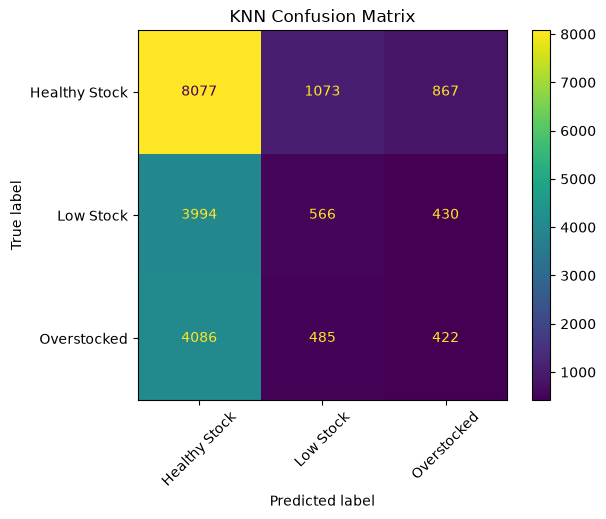

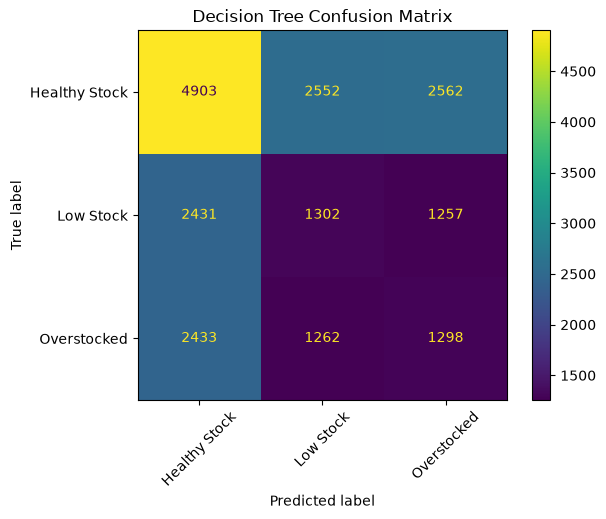

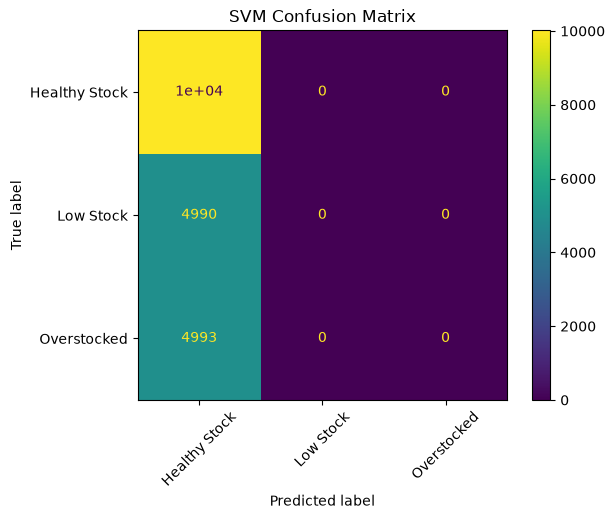

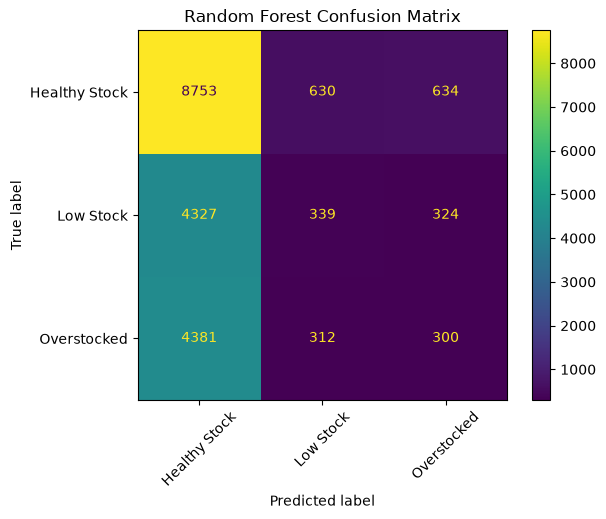

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

for name, predictions in models:
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        predictions,
        xticks_rotation=45
    )
    
    plt.title(name + " Confusion Matrix")
    plt.show()

In [ ]:
import joblib

# Save the models that were already trained
joblib.dump(knn, "../models/classification/baseline/knn.pkl")
joblib.dump(decision_tree, "../models/classification/baseline/decision_tree.pkl")
joblib.dump(svm_model, "../models/classification/baseline/svm.pkl")
joblib.dump(random_forest, "../models/classification/baseline/random_forest.pkl")

# Save scaler
joblib.dump(scaler, "../models/classification/baseline/scaler.pkl")

print("All baseline classification models saved successfully!")

All baseline classification models saved successfully!
